In [1]:
!pip install optuna
!pip install catboost
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 46.4 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [2]:
!pip install shap

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split ,GroupShuffleSplit, cross_val_score,cross_val_predict, GroupKFold, StratifiedGroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline as Pipe
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_selection import SelectFromModel
import optuna
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.ensemble import VotingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import average_precision_score, precision_recall_curve
from sklearn.ensemble import AdaBoostClassifier

In [4]:
df = pd.read_csv('preprocessing.csv')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,...,change,diabetesMed,readmitted,medical_specialty_grouped,primary_diag,secondary_diag,additional_diag,med_change,num_med,service_utilization
0,2278392,8222157,1,0,1,5,18,1,1,41,...,0,0,0,Pediatrics,4,0,0,0,0,0
1,149190,55629189,1,0,2,1,1,7,3,59,...,1,1,0,Unknown,0,4,0,1,1,0
2,64410,86047875,2,0,3,1,1,7,2,11,...,0,1,0,Unknown,0,4,0,0,1,3
3,500364,82442376,1,1,4,1,1,7,2,44,...,1,1,0,Unknown,0,4,1,1,1,0
4,16680,42519267,1,1,5,1,1,7,1,51,...,1,1,0,Unknown,8,8,4,0,2,0


In [5]:
numeric_cols = [
    'number_diagnoses', 'num_lab_procedures', 'num_med', 'time_in_hospital',
    'med_change', 'num_medications', 'number_outpatient', 'number_emergency',
    'number_inpatient', 'service_utilization', 'num_procedures'
]

categorical_cols = [
     'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
    'max_glu_serum', 'A1Cresult', 'medical_specialty_grouped', 'primary_diag'
]


In [6]:
# Features
X = df.drop(columns=['readmitted','encounter_id'])  # drop target + identifiers

# Target
y = df['readmitted']

In [7]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=15)

train_idx, test_idx = next(gss.split(X, y, groups=X['patient_nbr']))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups = X_train['patient_nbr']

In [8]:
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, val_idx = next(gss_val.split(X_train, y_train, groups=groups))

X_tr = X_train.iloc[train_idx]
X_val = X_train.iloc[val_idx]
y_tr = y_train.iloc[train_idx]
y_val = y_train.iloc[val_idx]

In [9]:
import matplotlib.pyplot as plt

In [10]:
def evaluate_model(model):

    # Train
    model.fit(X_train.drop(columns=['patient_nbr']), y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Accuracy
    acc = balanced_accuracy_score(y_test, y_pred)
    print("Balanced Accuracy:", acc)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:\n", cm)

    # Classification report
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))

    # ROC-AUC
    if hasattr(model, "predict_proba"):
      y_proba = model.predict_proba(X_test)[:, 1]
      pr_auc = average_precision_score(y_test, y_proba)
      print("PR-AUC:", pr_auc)



    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.show()

In [11]:
from fairlearn.metrics import MetricFrame
from sklearn.metrics import confusion_matrix
import numpy as np
import pandas as pd

In [12]:
def evaluate_fairness(model, sensitive_feature):
    """
    Evaluate fairness metrics for any model and protected attribute.
    Works for numeric, categorical (via preprocessor pipeline), and sklearn-like models.
    """
    # Train model
    model.fit(X_train.drop(columns=['patient_nbr']), y_train)

    # Predictions
    y_pred = model.predict(X_test.drop(columns=['patient_nbr']))

    # Sensitive feature
    sensitive = X_test[sensitive_feature]

    # Confusion matrix
    def safe_confusion(y_true, y_pred):
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        return tn, fp, fn, tp

    # Metric definitions
    def PPR(y_true, y_pred):
        return np.mean(y_pred == 1)

    def FPR(y_true, y_pred):
        tn, fp, fn, tp = safe_confusion(y_true, y_pred)
        return fp / (fp + tn) if (fp + tn) > 0 else 0

    def FNR(y_true, y_pred):
        tn, fp, fn, tp = safe_confusion(y_true, y_pred)
        return fn / (fn + tp) if (fn + tp) > 0 else 0

    metrics = {"PPR": PPR, "FPR": FPR, "FNR": FNR}

    # Fairlearn MetricFrame
    mf = MetricFrame(
        metrics=metrics,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    # Group size ratio
    gsr = sensitive.value_counts(normalize=True)

    # Combine results
    results = mf.by_group.copy()
    #results["GSR"] = gsr

    print(f"\n=== Fairness Metrics by Group for {type(model).__name__} ===")
    return results

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from fairlearn.metrics import (
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference,
    equal_opportunity_difference
)

def evaluate_model_with_fairness(model):
    """
    Train the model, predict, compute accuracy, and demographic parity for race, gender, age.
    """

    # 1️⃣ Train
    model.fit(X_train.drop(columns=['patient_nbr']), y_train)

    # 2️⃣ Predict
    y_pred = model.predict(X_test.drop(columns=['patient_nbr']))


    metrics = {}

    for feature in ['race', 'gender', 'age']:
        sf = X_test[feature]

        metrics[feature] = {
          #"dp_diff": demographic_parity_difference(y_test, y_pred, sensitive_features=sf),
          "dp_ratio": demographic_parity_ratio(y_test, y_pred, sensitive_features=sf),
          "eo_diff": equalized_odds_difference(y_test, y_pred, sensitive_features=sf),
          "eop_diff": equal_opportunity_difference(y_test, y_pred, sensitive_features=sf),
        }


        df = pd.DataFrame(metrics).T
    print(df)


# Modeling

In [14]:

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)


## Decstion tree

In [ ]:
base_dt = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=15,
    class_weight='balanced'
)

### Baseline

Fold recalls: [0.02247191 0.00164564 0.00560852 0.00166389 0.00991736]
Mean recalls: 0.008, Std: 0.008
Balanced Accuracy: 0.5045924619657824

Confusion Matrix:
 [[17633    48]
 [ 2325    28]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17681
           1       0.37      0.01      0.02      2353

    accuracy                           0.88     20034
   macro avg       0.63      0.50      0.48     20034
weighted avg       0.82      0.88      0.83     20034

PR-AUC: 0.2027706593862018


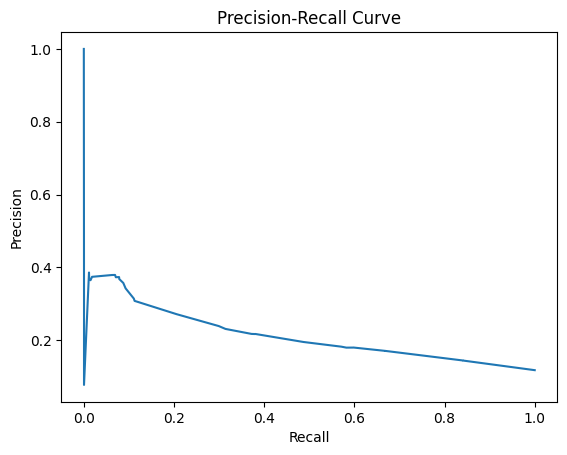

In [ ]:
pipe_baseTr = Pipe([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=15
))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_baseTr,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')
# Fit and predict
pipe_baseTr.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_baseTr)

In [ ]:
evaluate_model_with_fairness(pipe_baseTr)

        dp_ratio   eo_diff  eop_diff
race    0.000000  0.025287  0.025287
gender  0.685912  0.014443  0.014443
age     0.000000  0.100000  0.100000


In [ ]:
evaluate_fairness(pipe_baseTr, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.002962,0.002067,0.990513
2,0.007315,0.005010,0.974713
3,0.002208,0.002439,1.000000
4,0.000000,0.000000,1.000000
5,0.009585,0.010601,1.000000
6,0.000000,0.000000,1.000000


In [ ]:
evaluate_fairness(pipe_baseTr, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.000000,0.000000,0.000000
2,0.007576,0.000000,0.900000
3,0.016234,0.017857,1.000000
4,0.004323,0.004870,1.000000
5,0.006701,0.005848,0.986957
6,0.006471,0.003070,0.961661
7,0.001968,0.001992,0.998201
8,0.002915,0.001556,0.987597
9,0.002639,0.002010,0.992958


In [ ]:
evaluate_fairness(pipe_baseTr, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.003135,0.002827,0.994595
1,0.004571,0.002583,0.980151


### class weight

Fold recalls: [0.60561798 0.59243006 0.63712844 0.60122019 0.5338843 ]
Mean recalls: 0.594, Std: 0.034
Balanced Accuracy: 0.6133095803027412

Confusion Matrix:
 [[12265  5416]
 [ 1099  1254]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17681
           1       0.19      0.53      0.28      2353

    accuracy                           0.67     20034
   macro avg       0.55      0.61      0.53     20034
weighted avg       0.83      0.67      0.73     20034

PR-AUC: 0.2039353907257111


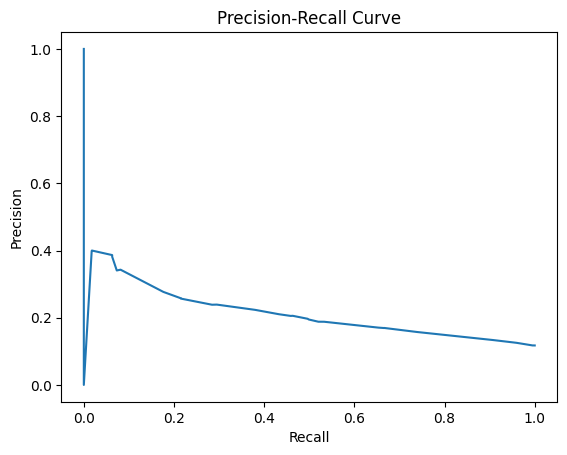

In [ ]:
pipe_dt = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_dt)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_dt,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')
# Fit and predict
pipe_dt.fit(X_train.drop(columns=['patient_nbr']), y_train)
evaluate_model(pipe_dt)

In [ ]:
evaluate_model_with_fairness(pipe_dt)

        dp_ratio   eo_diff  eop_diff
race    0.552751  0.384146  0.384146
gender  0.821829  0.070150  0.070150
age     0.133749  0.607143  0.607143


In [ ]:
evaluate_fairness(pipe_dt, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.339212,0.311337,0.457589
2,0.336729,0.314176,0.487356
3,0.251656,0.236585,0.604651
4,0.187500,0.129310,0.250000
5,0.290735,0.257951,0.400000
6,0.247265,0.235577,0.634146


In [ ]:
evaluate_fairness(pipe_dt, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.071429,0.071429,0.000000
2,0.196970,0.180328,0.600000
3,0.224026,0.185714,0.392857
4,0.257925,0.217532,0.423077
5,0.264433,0.223977,0.434783
6,0.240370,0.211119,0.485623
7,0.299803,0.274832,0.519784
8,0.361516,0.337778,0.472868
9,0.460862,0.441876,0.406103


In [ ]:
evaluate_fairness(pipe_dt, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.362563,0.335183,0.435521
1,0.297965,0.272414,0.505671


### feature selection

Fold recalls: [0.60898876 0.60559517 0.58777342 0.53632834 0.56363636]
Mean recalls: 0.580, Std: 0.027
Balanced Accuracy: 0.6147791359228801

Confusion Matrix:
 [[11543  6138]
 [  996  1357]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17681
           1       0.18      0.58      0.28      2353

    accuracy                           0.64     20034
   macro avg       0.55      0.61      0.52     20034
weighted avg       0.83      0.64      0.71     20034

PR-AUC: 0.20568713310224968


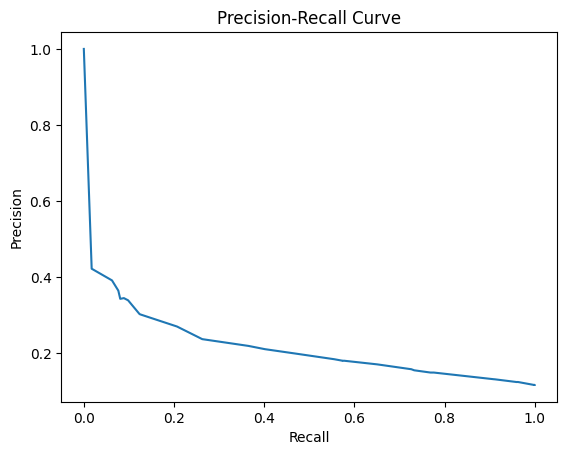

In [ ]:
pipe_tr = ImbPipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    random_state=15,
    class_weight='balanced'
))),
    ('model', base_dt)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_tr,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)
print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

# Fit and predict
pipe_tr.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_tr)

In [ ]:
evaluate_model_with_fairness(pipe_tr)

        dp_ratio   eo_diff  eop_diff
race    0.566812  0.432927  0.432927
gender  0.851881  0.065535  0.065535
age     0.061698  0.629108  0.629108


In [ ]:
evaluate_fairness(pipe_tr, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.385931,0.357881,0.409598
2,0.366249,0.341586,0.441379
3,0.264901,0.241463,0.511628
4,0.218750,0.163793,0.250000
5,0.268371,0.250883,0.566667
6,0.280088,0.276442,0.682927


In [ ]:
evaluate_fairness(pipe_tr, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.035714,0.035714,0.000000
2,0.189394,0.163934,0.500000
3,0.211039,0.171429,0.392857
4,0.256484,0.220779,0.461538
5,0.291237,0.249123,0.395652
6,0.283513,0.255798,0.456869
7,0.350317,0.323625,0.456835
8,0.405831,0.380889,0.420155
9,0.506596,0.489112,0.370892


In [ ]:
evaluate_fairness(pipe_tr, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.401383,0.373613,0.393822
1,0.341931,0.316074,0.459357


## XGboost

In [41]:
base_xgb= XGBClassifier(
    colsample_bytree=1.0,
    learning_rate=0.001,
    max_depth=4,
    min_child_weight=1,
    n_estimators=1000,
    subsample=1.0,
    random_state=15,
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1]),
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1)

### Baseline

Fold recalls: [0.02191011 0.00877674 0.00785193 0.00554631 0.01157025]
Mean recalls: 0.011, Std: 0.006


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Balanced Accuracy: 0.5039816464008116

Confusion Matrix:
 [[17664    17]
 [ 2332    21]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17681
           1       0.55      0.01      0.02      2353

    accuracy                           0.88     20034
   macro avg       0.72      0.50      0.48     20034
weighted avg       0.84      0.88      0.83     20034

PR-AUC: 0.22487791270397534


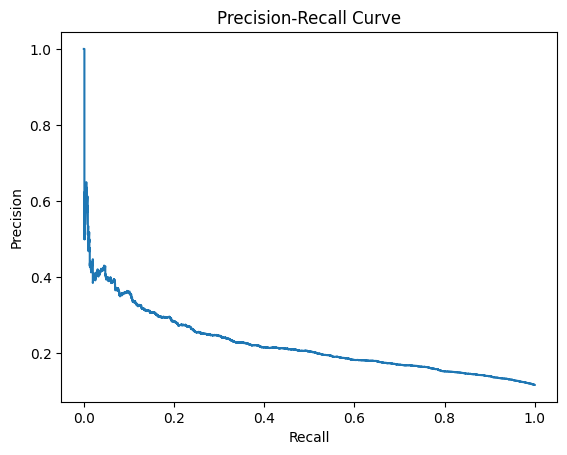

In [ ]:

pipe_baseXgb= Pipe([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=15
    ))
])

# CV
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_baseXgb,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_baseXgb.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_baseXgb)

In [ ]:
evaluate_model_with_fairness(pipe_baseXgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


        dp_ratio   eo_diff  eop_diff
race     0.00000  0.018391  0.018391
gender   0.61622  0.004392  0.004392
age      0.00000  0.035714  0.035714


In [ ]:
evaluate_fairness(pipe_baseXgb, 'race')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.001346,0.000536,0.992746
2,0.004441,0.002653,0.981609
3,0.000000,0.000000,1.000000
4,0.000000,0.000000,1.000000
5,0.003195,0.003534,1.000000
6,0.000000,0.000000,1.000000


In [ ]:
evaluate_fairness(pipe_baseXgb, 'age')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.000000,0.000000,0.000000
2,0.000000,0.000000,1.000000
3,0.019481,0.017857,0.964286
4,0.004323,0.004870,1.000000
5,0.002577,0.000585,0.982609
6,0.005239,0.002046,0.964856
7,0.000219,0.000249,1.000000
8,0.000777,0.000222,0.995349
9,0.000586,0.000000,0.995305


In [ ]:
evaluate_fairness(pipe_baseXgb, 'gender')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:54:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.001475,0.000733,0.993050
1,0.002394,0.001230,0.988658


### Class weight

Fold recalls: [0.61235955 0.61162918 0.63432417 0.59400998 0.61212121]
Mean recalls: 0.613, Std: 0.013


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:40:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:40:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Balanced Accuracy: 0.6189158177555374

Confusion Matrix:
 [[11013  6668]
 [  906  1447]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.62      0.74     17681
           1       0.18      0.61      0.28      2353

    accuracy                           0.62     20034
   macro avg       0.55      0.62      0.51     20034
weighted avg       0.84      0.62      0.69     20034

PR-AUC: 0.2203961387494609


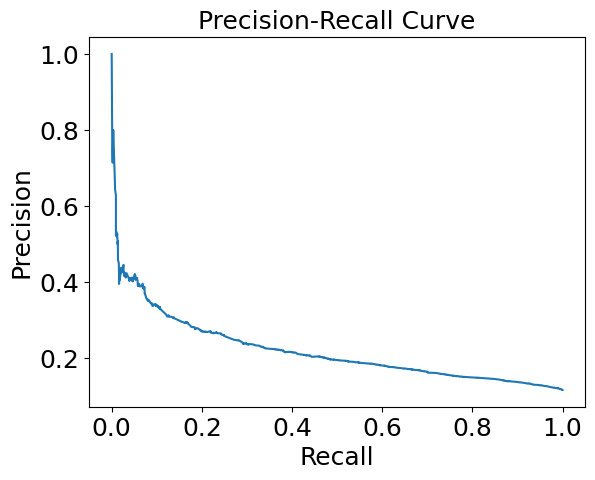

In [42]:

pipe_xgb= ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_xgb)
])

# CV
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_xgb,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_xgb.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_xgb)

In [ ]:
evaluate_model_with_fairness(pipe_xgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


        dp_ratio   eo_diff  eop_diff
race    0.580929  0.384146  0.384146
gender  0.857106  0.061186  0.061186
age     0.113553  0.678571  0.678571


In [ ]:
evaluate_fairness(pipe_xgb, 'race')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:57:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.416897,0.387660,0.369978
2,0.395507,0.371058,0.413793
3,0.309051,0.285366,0.465116
4,0.242188,0.189655,0.250000
5,0.322684,0.300353,0.466667
6,0.297593,0.290865,0.634146


In [ ]:
evaluate_fairness(pipe_xgb, 'age')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:58:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.071429,0.071429,0.000000
2,0.227273,0.196721,0.400000
3,0.253247,0.210714,0.321429
4,0.301153,0.261364,0.384615
5,0.314948,0.271930,0.365217
6,0.305701,0.276944,0.424920
7,0.377651,0.349266,0.417266
8,0.438290,0.413778,0.390698
9,0.545295,0.526298,0.321596


In [ ]:
evaluate_fairness(pipe_xgb, 'gender')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:58:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.433472,0.405131,0.357529
1,0.371531,0.344238,0.418715


### feature selection

Fold recalls: [0.62191011 0.61492046 0.61974201 0.61120355 0.59504132]
Mean recalls: 0.613, Std: 0.010


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:59:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:59:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:59:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:59:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Balanced Accuracy: 0.6183566806678484

Confusion Matrix:
 [[10873  6808]
 [  890  1463]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.61      0.74     17681
           1       0.18      0.62      0.28      2353

    accuracy                           0.62     20034
   macro avg       0.55      0.62      0.51     20034
weighted avg       0.84      0.62      0.68     20034

PR-AUC: 0.213333739988367


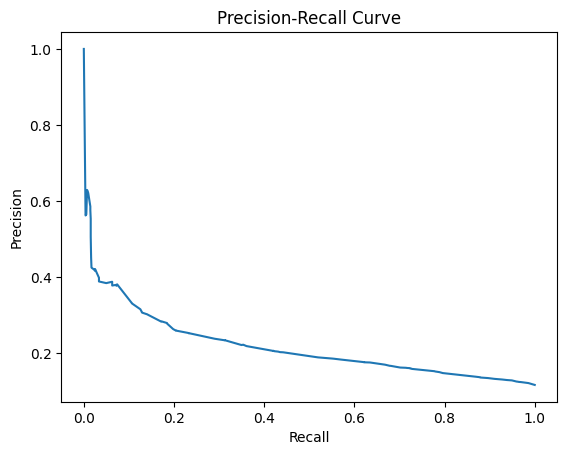

In [ ]:
pipe_fXgb = ImbPipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.01,
        use_label_encoder=False,
        scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
        eval_metric='logloss',
        random_state=15), threshold=0.02)),
    ('classification', base_xgb)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_fXgb,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_fXgb.fit(X_train.drop(columns=['patient_nbr']),y_train)
evaluate_model(pipe_fXgb)

In [ ]:
evaluate_model_with_fairness(pipe_fXgb)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


        dp_ratio   eo_diff  eop_diff
race    0.569526  0.384146  0.384146
gender  0.856413  0.063237  0.063237
age     0.110714  0.685446  0.685446


In [ ]:
evaluate_fairness(pipe_fXgb, 'race')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:14] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.425244,0.396157,0.362723
2,0.401515,0.377247,0.409195
3,0.320088,0.297561,0.465116
4,0.242188,0.189655,0.250000
5,0.329073,0.303887,0.433333
6,0.301969,0.295673,0.634146


In [ ]:
evaluate_fairness(pipe_fXgb, 'age')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.071429,0.071429,0.000000
2,0.227273,0.196721,0.400000
3,0.259740,0.217857,0.321429
4,0.305476,0.266234,0.384615
5,0.319588,0.277193,0.365217
6,0.313713,0.285471,0.421725
7,0.384430,0.355987,0.410072
8,0.445870,0.420667,0.378295
9,0.556142,0.537688,0.314554


In [ ]:
evaluate_fairness(pipe_fXgb, 'gender')

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:00:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.441955,0.413717,0.349807
1,0.378496,0.351371,0.413043


## lightgbm

In [19]:
from lightgbm import LGBMClassifier

scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

base_lgb = LGBMClassifier(
    colsample_bytree=0.8,      # fraction of features per tree
    learning_rate=0.03,        # step size
    max_depth=4,               # max depth of each tree
    min_child_weight=5,        # minimum sum of instance weights in a leaf (LGBM uses min_child_samples)
    n_estimators=400,          # number of boosting rounds
    subsample=0.8,             # fraction of rows per tree
    random_state=15,
    class_weight=None,          # will use scale_pos_weight manually
    scale_pos_weight=scale_pos_weight,  # same as XGBoost
    n_jobs=-1,
    verbose=-1
)

### Baseline

Fold recalls: [0.01404494 0.00438837 0.00448682 0.00443705 0.01157025]
Mean recalls: 0.008, Std: 0.004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Balanced Accuracy: 0.5036132149125433

Confusion Matrix:
 [[17666    15]
 [ 2334    19]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17681
           1       0.56      0.01      0.02      2353

    accuracy                           0.88     20034
   macro avg       0.72      0.50      0.48     20034
weighted avg       0.85      0.88      0.83     20034



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PR-AUC: 0.2238699907237553


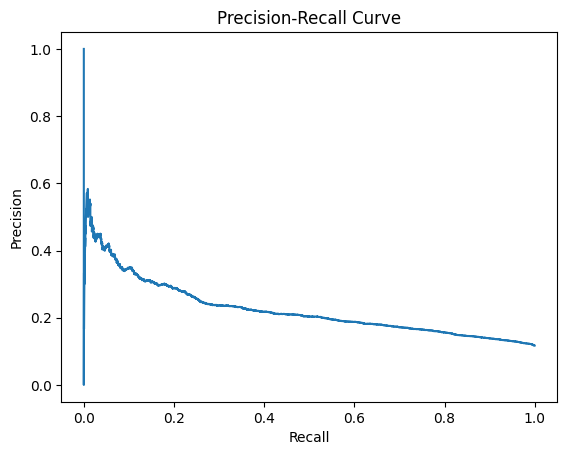

In [18]:

pipe_baseLg= ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', LGBMClassifier(
    colsample_bytree=0.8,      # fraction of features per tree
    learning_rate=0.03,        # step size
    max_depth=4,               # max depth of each tree
    min_child_weight=1,        # minimum sum of instance weights in a leaf (LGBM uses min_child_samples)
    n_estimators=400,          # number of boosting rounds
    subsample=0.8,             # fraction of rows per tree
    random_state=15,
    n_jobs=-1,
    verbose=-1
))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_baseLg,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_baseLg.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_baseLg)

In [20]:
evaluate_model_with_fairness(pipe_baseLg)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


        dp_ratio   eo_diff  eop_diff
race    0.000000  0.018391  0.018391
gender  0.753158  0.002502  0.002502
age     0.000000  0.035714  0.035714


In [21]:
evaluate_fairness(pipe_baseLg, 'race')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.001414,0.000766,0.993862
2,0.003135,0.001179,0.981609
3,0.000000,0.000000,1.000000
4,0.000000,0.000000,1.000000
5,0.003195,0.003534,1.000000
6,0.000000,0.000000,1.000000


In [22]:
evaluate_fairness(pipe_baseLg, 'age')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.000000,0.000000,0.000000
2,0.000000,0.000000,1.000000
3,0.009740,0.007143,0.964286
4,0.004323,0.004870,1.000000
5,0.002577,0.000000,0.978261
6,0.004931,0.002046,0.968051
7,0.000000,0.000000,1.000000
8,0.001166,0.000889,0.996899
9,0.000293,0.000000,0.997653


In [23]:
evaluate_fairness(pipe_baseLg, 'gender')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.001475,0.000733,0.993050
1,0.001959,0.000984,0.990548


### class weight

Fold recalls: [0.59157303 0.58310477 0.58833427 0.59400998 0.59559229]
Mean recalls: 0.591, Std: 0.004


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Balanced Accuracy: 0.6269987642594439

Confusion Matrix:
 [[11389  6292]
 [  918  1435]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.64      0.76     17681
           1       0.19      0.61      0.28      2353

    accuracy                           0.64     20034
   macro avg       0.56      0.63      0.52     20034
weighted avg       0.84      0.64      0.70     20034



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PR-AUC: 0.22612026534635032


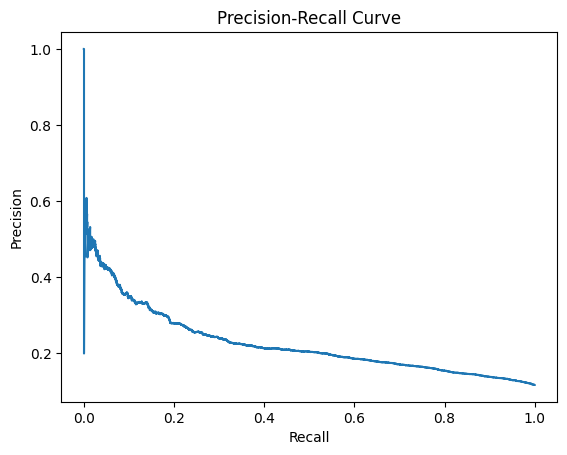

In [24]:
pipe_lg= ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_lgb)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_lg,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_lg.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_lg)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


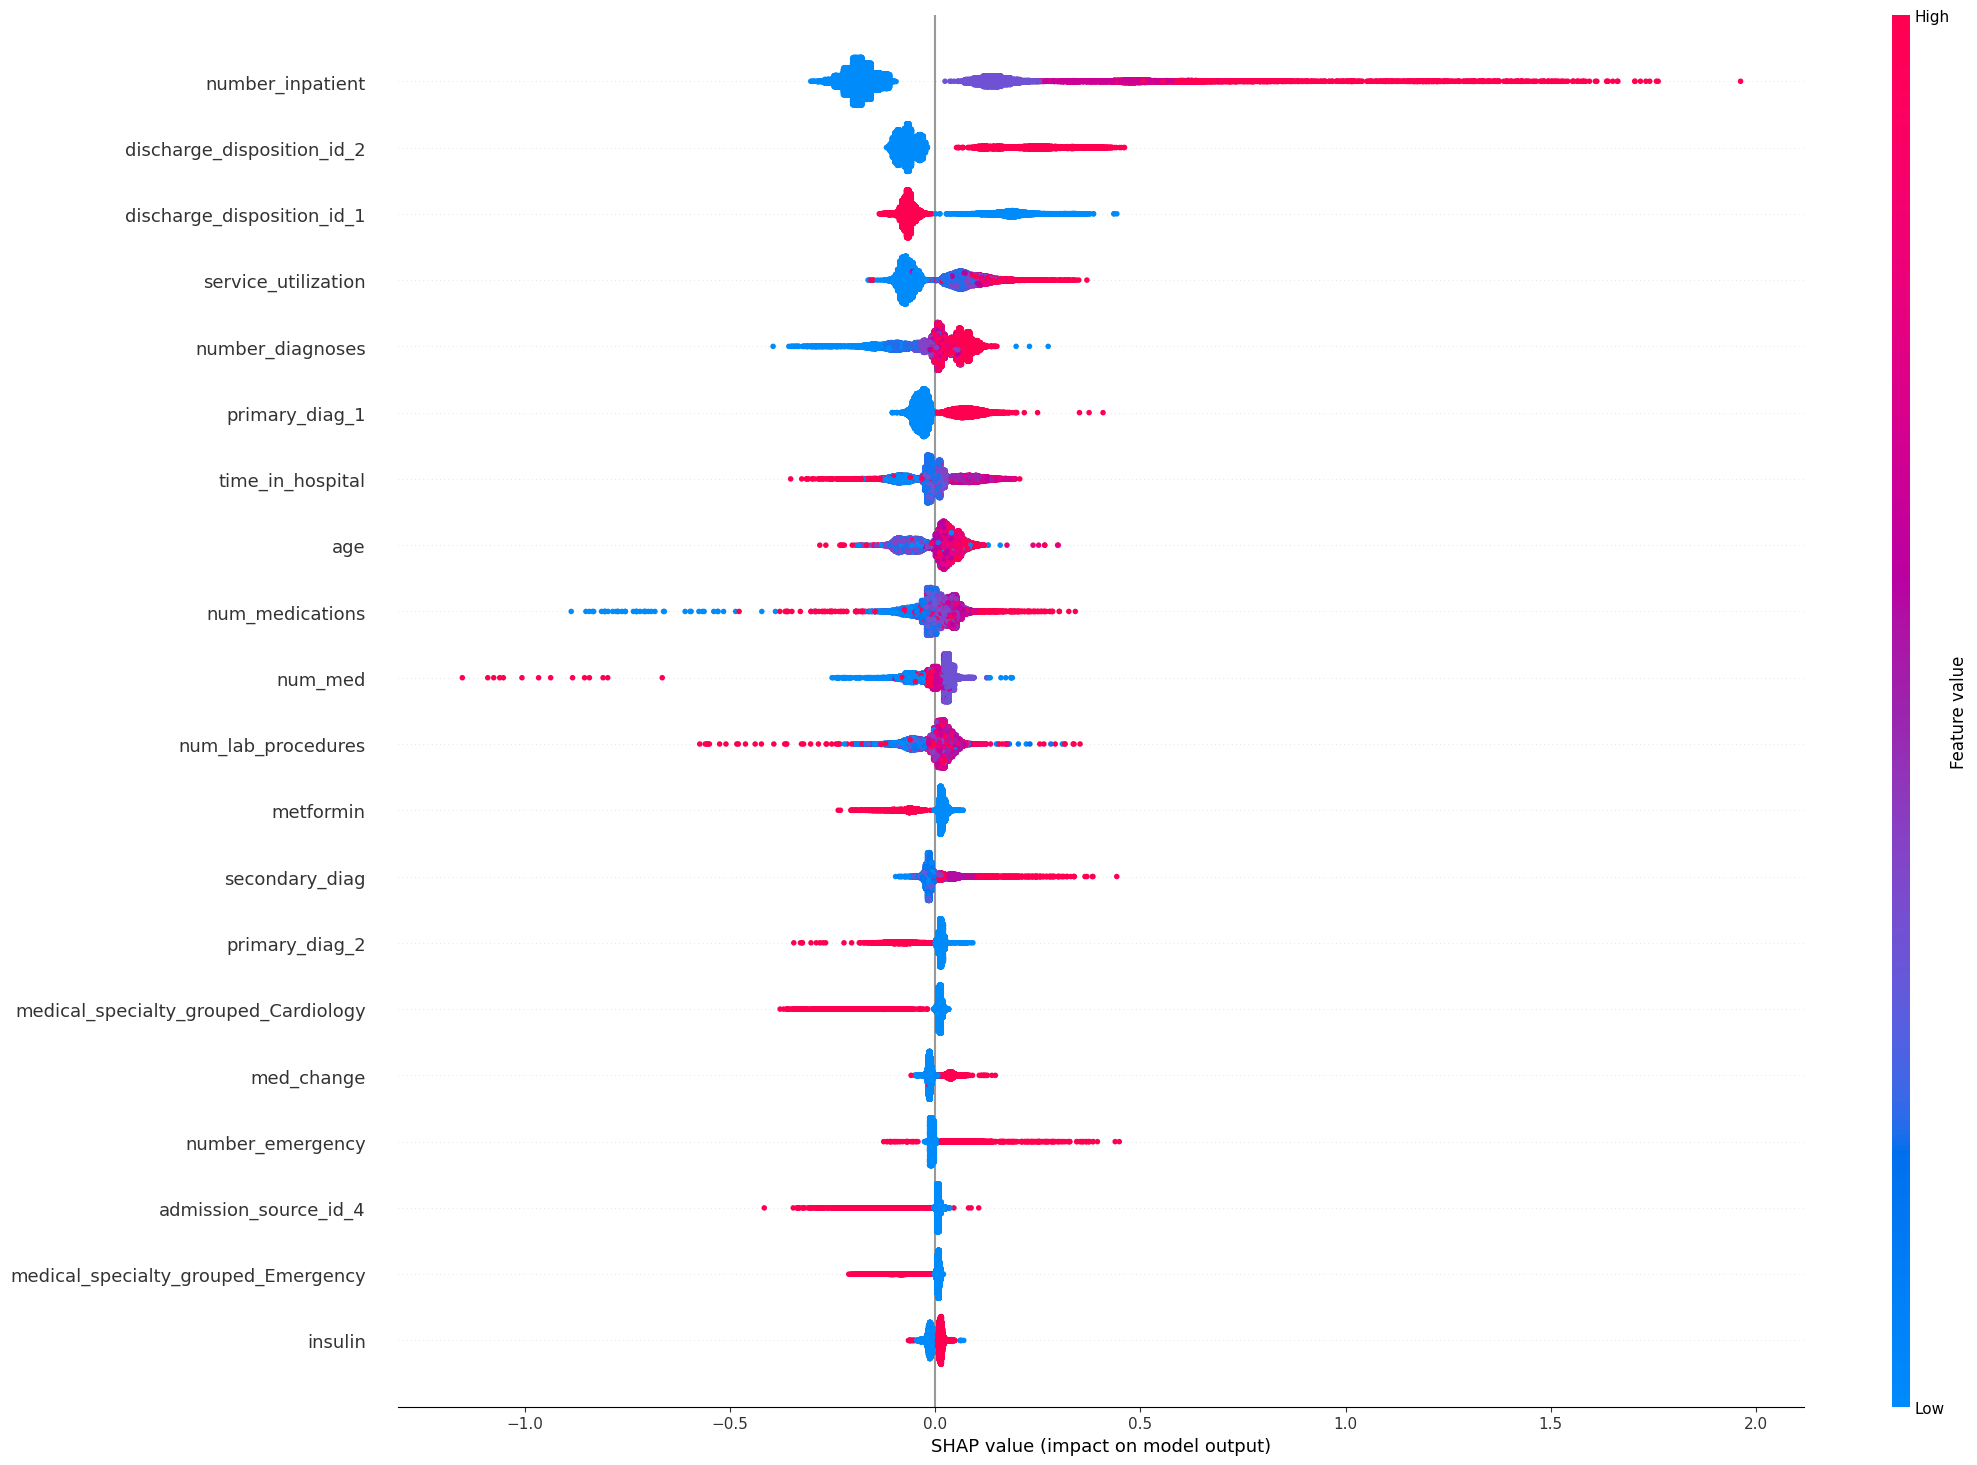

In [25]:
import shap
import pandas as pd

# Extract model
model = pipe_lg.named_steps['model']

# Transform data
X_test_transformed = pipe_lg.named_steps['preprocessor'].transform(
    X_test.drop(columns=['patient_nbr'])
)

# Get feature names
feature_names = pipe_lg.named_steps['preprocessor'].get_feature_names_out()


clean_feature_names = [name.split("__")[-1] for name in feature_names]

# Convert to DataFrame
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=clean_feature_names
)

# SHAP
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X_test_transformed_df)

# Plot

plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 18,
    "axes.labelsize": 18,
    "ytick.labelsize": 18,
    "xtick.labelsize": 18
})

shap.summary_plot(
    shap_values,
    X_test_transformed_df,
    color=None,
    show=False,
    max_display=20,
    plot_size=(22, 15)
)

plt.tight_layout()
plt.savefig("shap_summary_gray.png", dpi=300)
plt.show()

In [26]:
evaluate_model_with_fairness(pipe_lg)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


        dp_ratio   eo_diff  eop_diff
race    0.576969  0.432927  0.432927
gender  0.857212  0.058408  0.053637
age     0.067100  0.678571  0.678571


In [27]:
evaluate_fairness(pipe_lg, 'race')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.390710,0.358647,0.375558
2,0.406217,0.383436,0.416092
3,0.300221,0.270732,0.418605
4,0.234375,0.181034,0.250000
5,0.281150,0.257951,0.500000
6,0.249453,0.242788,0.682927


In [28]:
evaluate_fairness(pipe_lg, 'age')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.035714,0.035714,0.000000
2,0.196970,0.180328,0.600000
3,0.272727,0.232143,0.321429
4,0.311239,0.271104,0.371795
5,0.306701,0.256725,0.321739
6,0.287211,0.259891,0.456869
7,0.359939,0.330595,0.428058
8,0.420797,0.393333,0.387597
9,0.517444,0.495477,0.328638


In [29]:
evaluate_fairness(pipe_lg, 'gender')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.412725,0.382723,0.366023
1,0.353793,0.324314,0.419660


### feature selection

Fold recalls: [0.59382022 0.58529896 0.58553001 0.59400998 0.59889807]
Mean recalls: 0.592, Std: 0.005


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Balanced Accuracy: 0.6279182325345436

Confusion Matrix:
 [[11414  6267]
 [  917  1436]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.65      0.76     17681
           1       0.19      0.61      0.29      2353

    accuracy                           0.64     20034
   macro avg       0.56      0.63      0.52     20034
weighted avg       0.84      0.64      0.70     20034



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PR-AUC: 0.22700886518720587


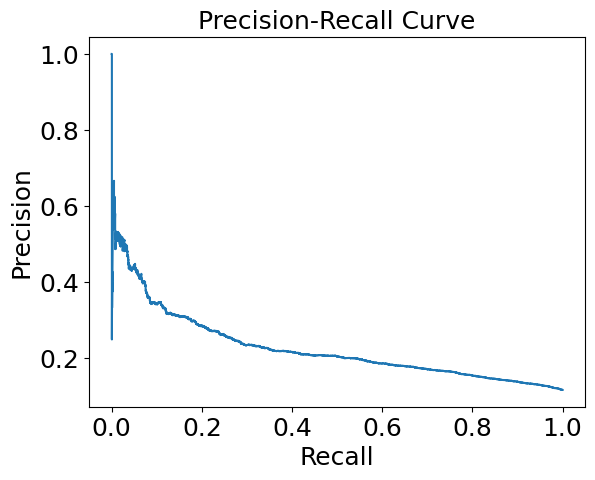

In [34]:
pipe_fLg= ImbPipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectFromModel(LGBMClassifier(
    colsample_bytree=0.8,      # fraction of features per tree
    learning_rate=0.03,        # step size
    max_depth=4,               # max depth of each tree
    min_child_weight=1,        # minimum sum of instance weights in a leaf (LGBM uses min_child_samples)
    n_estimators=400,          # number of boosting rounds
    subsample=0.8,             # fraction of rows per tree
    random_state=15,
    n_jobs=-1,
    verbose=-1
), threshold=0.02)),
   ('model', base_lgb)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_fLg,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_fLg.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_fLg)


In [35]:
evaluate_model_with_fairness(pipe_fLg)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


        dp_ratio   eo_diff  eop_diff
race    0.565607  0.432927  0.432927
gender  0.860458  0.056929  0.050974
age     0.000000  0.680751  0.680751


In [36]:
evaluate_fairness(pipe_fLg, 'race')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.389970,0.357651,0.374442
2,0.406217,0.383142,0.413793
3,0.289183,0.263415,0.465116
4,0.234375,0.181034,0.250000
5,0.284345,0.261484,0.500000
6,0.229759,0.221154,0.682927


In [38]:
evaluate_fairness(pipe_fLg, 'age')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.000000,0.000000,0.000000
2,0.166667,0.155738,0.700000
3,0.279221,0.239286,0.321429
4,0.319885,0.280844,0.371795
5,0.305155,0.256725,0.334783
6,0.288136,0.260914,0.456869
7,0.360813,0.330595,0.420863
8,0.419048,0.391556,0.389147
9,0.515685,0.492127,0.319249


In [37]:
evaluate_fairness(pipe_fLg, 'gender')

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SelectFromModel was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.410788,0.380628,0.366795
1,0.353466,0.323699,0.417769


## Random Forest

In [39]:
base_rf= RandomForestClassifier(
    n_estimators=400,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=15,
    class_weight='balanced'
)

### Baseline

Fold recalls: [0.00224719 0.00054855 0.         0.         0.00055096]
Mean recalls: 0.001, Std: 0.001
Balanced Accuracy: 0.5

Confusion Matrix:
 [[17681     0]
 [ 2353     0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17681
           1       0.00      0.00      0.00      2353

    accuracy                           0.88     20034
   macro avg       0.44      0.50      0.47     20034
weighted avg       0.78      0.88      0.83     20034



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


PR-AUC: 0.22627906629159578


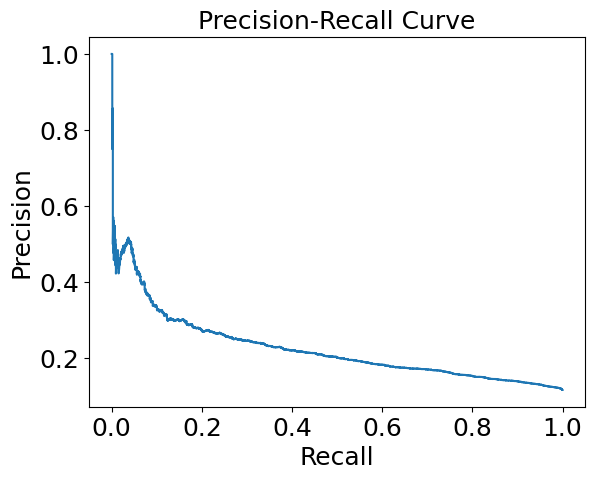

In [ ]:
pipe_baseRf = Pipe([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=15
))
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_baseRf,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_baseRf.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_baseRf)


In [ ]:
evaluate_model_with_fairness(pipe_baseRf)

        dp_ratio  eo_diff  eop_diff
race         NaN      0.0       0.0
gender       NaN      0.0       0.0
age          NaN      0.0       0.0


In [ ]:
evaluate_fairness(pipe_baseRf, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
5,0.0,0.0,1.0
6,0.0,0.0,1.0


In [ ]:
evaluate_fairness(pipe_baseRf, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0
5,0.0,0.0,1.0
6,0.0,0.0,1.0
7,0.0,0.0,1.0
8,0.0,0.0,1.0
9,0.0,0.0,1.0


In [ ]:
evaluate_fairness(pipe_baseRf, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.0,0.0,1.0
1,0.0,0.0,1.0


### Class weight

Fold recalls: [0.5988764  0.60778936 0.6174986  0.59345535 0.59393939]
Mean recalls: 0.602, Std: 0.009
Balanced Accuracy: 0.6213276282537821

Confusion Matrix:
 [[11211  6470]
 [  921  1432]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.63      0.75     17681
           1       0.18      0.61      0.28      2353

    accuracy                           0.63     20034
   macro avg       0.55      0.62      0.52     20034
weighted avg       0.84      0.63      0.70     20034

PR-AUC: 0.21493817468520315


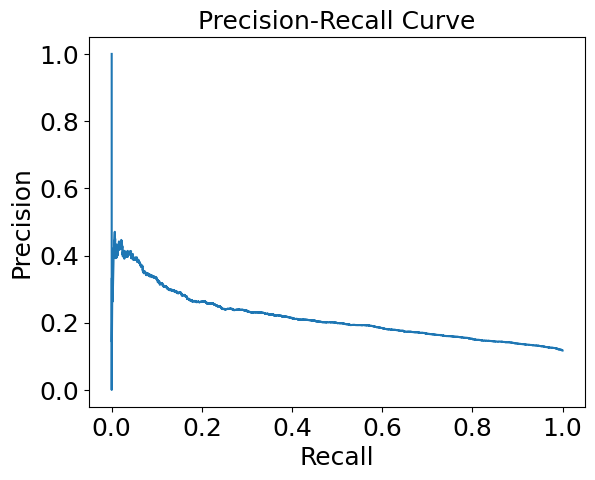

In [40]:
pipe_rf = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_rf)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_rf,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_rf.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_rf)


In [ ]:
evaluate_model_with_fairness(pipe_rf)

        dp_ratio   eo_diff  eop_diff
race    0.581825  0.408537  0.408537
gender  0.829712  0.072721  0.065059
age     0.061508  0.678571  0.678571


In [ ]:
evaluate_fairness(pipe_rf, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.402827,0.372579,0.376674
2,0.397335,0.373416,0.416092
3,0.304636,0.282927,0.488372
4,0.234375,0.181034,0.250000
5,0.313099,0.289753,0.466667
6,0.286652,0.281250,0.658537


In [ ]:
evaluate_fairness(pipe_rf, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.035714,0.035714,0.000000
2,0.234848,0.204918,0.400000
3,0.282468,0.242857,0.321429
4,0.315562,0.275974,0.371795
5,0.319072,0.276608,0.365217
6,0.292758,0.263302,0.431310
7,0.360157,0.332338,0.438849
8,0.426433,0.400667,0.393798
9,0.536500,0.516248,0.321596


In [ ]:
evaluate_fairness(pipe_rf, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.427847,0.399372,0.362162
1,0.354990,0.326651,0.427221


### feature selection

Fold recalls: [0.58483146 0.55732309 0.59394279 0.59511925 0.56749311]
Mean recalls: 0.580, Std: 0.015
Balanced Accuracy: 0.6166132411363661

Confusion Matrix:
 [[11683  5998]
 [ 1006  1347]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     17681
           1       0.18      0.57      0.28      2353

    accuracy                           0.65     20034
   macro avg       0.55      0.62      0.52     20034
weighted avg       0.83      0.65      0.71     20034

PR-AUC: 0.20942495612397782


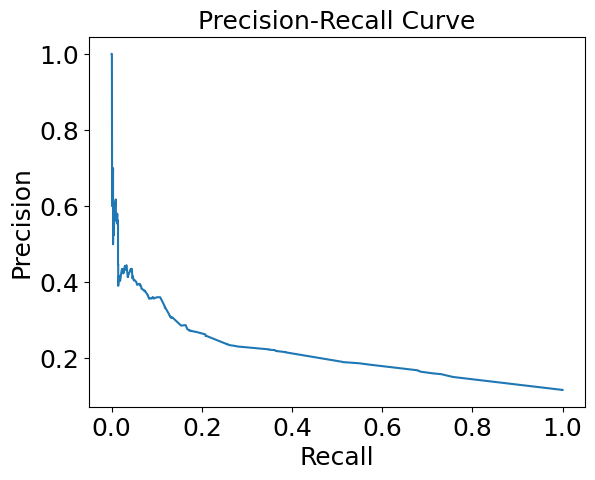

In [ ]:
pipe_fRf = ImbPipeline([
    ('preprocessor', preprocessor),
       ('feature_selection', SelectFromModel(RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=15,
    class_weight='balanced'
), threshold=0.05)),
    ('model', base_rf)
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_fRf,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

# Fit and predict
pipe_fRf.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_fRf)

In [ ]:
evaluate_model_with_fairness(pipe_fRf)

        dp_ratio   eo_diff  eop_diff
race    0.537865  0.384146  0.384146
gender  0.829215  0.067470  0.062965
age     0.115528  0.640845  0.640845


In [ ]:
evaluate_fairness(pipe_fRf, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.377651,0.348312,0.408482
2,0.354232,0.332449,0.475862
3,0.269316,0.253659,0.581395
4,0.203125,0.146552,0.250000
5,0.319489,0.293286,0.433333
6,0.286652,0.278846,0.634146


In [ ]:
evaluate_fairness(pipe_fRf, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.071429,0.071429,0.000000
2,0.234848,0.204918,0.400000
3,0.237013,0.200000,0.392857
4,0.276657,0.237013,0.410256
5,0.281959,0.240936,0.413043
6,0.270878,0.241814,0.456869
7,0.328231,0.301718,0.480216
8,0.396113,0.370222,0.423256
9,0.509235,0.490452,0.359155


In [ ]:
evaluate_fairness(pipe_fRf, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.397787,0.370262,0.399228
1,0.329851,0.302792,0.462193


## imblearn ensemble

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier , EasyEnsembleClassifier ,RUSBoostClassifier , BalancedBaggingClassifier

Fold recalls: [0.00730337 0.00054855 0.00168256 0.00388242 0.0077135 ]
Mean recalls: 0.004, Std: 0.003
Balanced Accuracy: 0.5007651419200352

Confusion Matrix:
 [[17678     3]
 [ 2349     4]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17681
           1       0.57      0.00      0.00      2353

    accuracy                           0.88     20034
   macro avg       0.73      0.50      0.47     20034
weighted avg       0.85      0.88      0.83     20034

PR-AUC: 0.2206005128919546


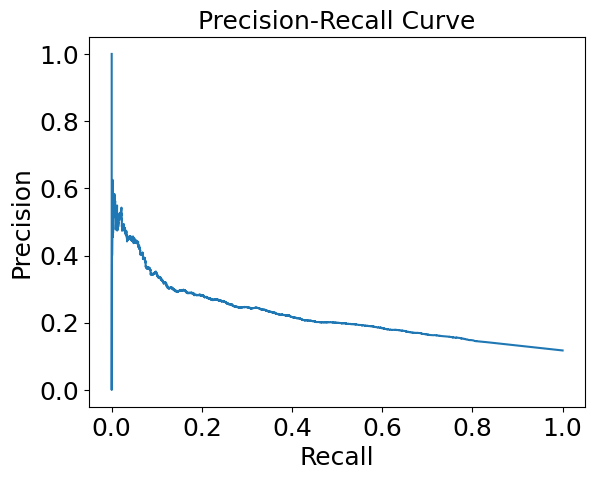

In [ ]:
base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=15,
)

base_ada= AdaBoostClassifier(
    estimator=base_estimator,
    learning_rate=0.01,
    n_estimators=400,
    random_state=15
)

pipe_baseAda = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_ada )
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_baseAda,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_baseAda.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_baseAda)

Fold recalls: [0.55393258 0.61162918 0.57431296 0.5391015  0.58953168]
Mean recalls: 0.574, Std: 0.026
Balanced Accuracy: 0.6164830714648684

Confusion Matrix:
 [[11205  6476]
 [  943  1410]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.63      0.75     17681
           1       0.18      0.60      0.28      2353

    accuracy                           0.63     20034
   macro avg       0.55      0.62      0.51     20034
weighted avg       0.84      0.63      0.70     20034

PR-AUC: 0.1813362234021744


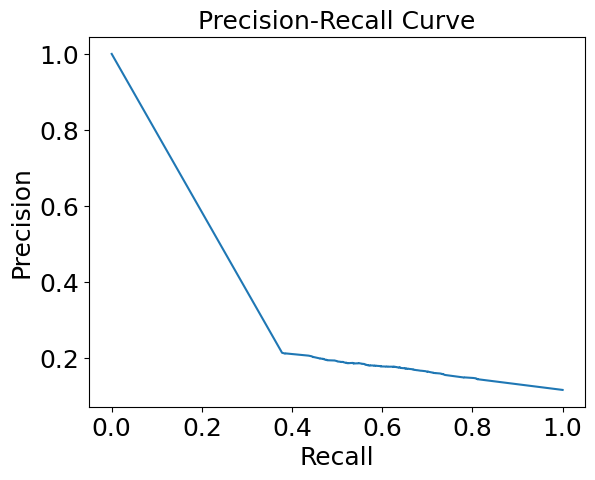

In [ ]:
base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=15,
)

base_ada= AdaBoostClassifier(
    estimator=base_estimator,
    learning_rate=0.01,
    n_estimators=400,
    random_state=15
)

pipe_ada = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_ada )
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_ada,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_ada.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_ada)

In [ ]:
evaluate_model_with_fairness(pipe_ada)

        dp_ratio   eo_diff  eop_diff
race    0.559718  0.384146  0.384146
gender  0.852808  0.065244  0.065244
age     0.115528  0.664319  0.664319


In [ ]:
evaluate_fairness(pipe_ada, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.404780,0.376407,0.388393
2,0.387409,0.363101,0.422989
3,0.295806,0.270732,0.465116
4,0.226562,0.172414,0.250000
5,0.300319,0.275618,0.466667
6,0.291028,0.283654,0.634146


In [ ]:
evaluate_fairness(pipe_ada, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.071429,0.071429,0.000000
2,0.204545,0.180328,0.500000
3,0.233766,0.192857,0.357143
4,0.275216,0.237013,0.423077
5,0.305670,0.262573,0.373913
6,0.292758,0.265348,0.450479
7,0.365406,0.337814,0.435252
8,0.427794,0.402889,0.398450
9,0.537672,0.519598,0.335681


In [ ]:
evaluate_fairness(pipe_ada, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.422130,0.394136,0.371429
1,0.359996,0.333538,0.436673


Fold recalls: [0.65337079 0.64509051 0.65395401 0.66444814 0.65730028]
Mean recalls: 0.655, Std: 0.006
Balanced Accuracy: 0.6172269891544664

Confusion Matrix:
 [[10014  7667]
 [  781  1572]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.57      0.70     17681
           1       0.17      0.67      0.27      2353

    accuracy                           0.58     20034
   macro avg       0.55      0.62      0.49     20034
weighted avg       0.84      0.58      0.65     20034

PR-AUC: 0.17851117334467254


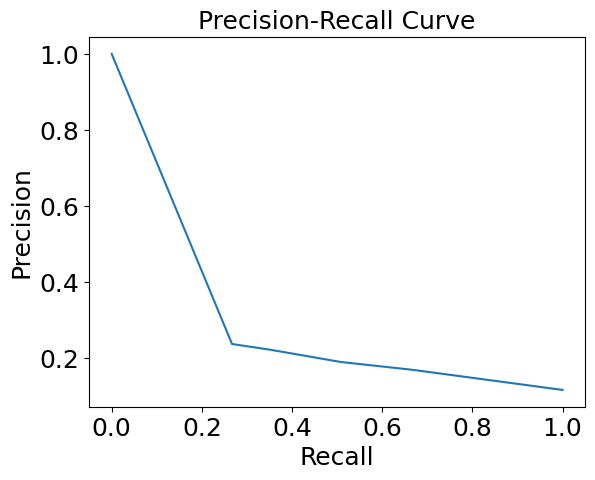

In [ ]:
#feature selection
feature_selector = SelectFromModel(
    estimator=DecisionTreeClassifier(max_depth=5),
    threshold=0.05

)
base_ada = AdaBoostClassifier(
    estimator=base_estimator,
    learning_rate = 0.01,
    n_estimators =400,
    random_state=15
)

pipe_fAda = ImbPipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('model', base_ada ) ])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_fAda,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_fAda.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_fAda)

In [ ]:
evaluate_model_with_fairness(pipe_fAda)

        dp_ratio   eo_diff  eop_diff
race    0.696925  0.213415  0.213415
gender  0.874431  0.062808  0.042646
age     0.212006  0.750000  0.750000


In [ ]:
evaluate_fairness(pipe_fAda, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.470818,0.441706,0.316964
2,0.456897,0.434719,0.370115
3,0.386313,0.363415,0.395349
4,0.328125,0.284483,0.250000
5,0.351438,0.328622,0.433333
6,0.369803,0.353365,0.463415


In [ ]:
evaluate_fairness(pipe_fAda, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.142857,0.142857,0.000000
2,0.333333,0.303279,0.300000
3,0.311688,0.267857,0.250000
4,0.361671,0.326299,0.358974
5,0.379381,0.336842,0.304348
6,0.365485,0.337995,0.376997
7,0.433632,0.406024,0.366906
8,0.493683,0.467778,0.325581
9,0.593081,0.574874,0.279343


In [ ]:
evaluate_fairness(pipe_fAda, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.489350,0.462513,0.312741
1,0.427903,0.399705,0.355388


Fold recalls: [0.01292135 0.01042238 0.00729108 0.00776484 0.00606061]
Mean recalls: 0.009, Std: 0.002
Balanced Accuracy: 0.5020126363251189

Confusion Matrix:
 [[17662    19]
 [ 2341    12]]

Classification Report:

              precision    recall  f1-score   support

           0       0.88      1.00      0.94     17681
           1       0.39      0.01      0.01      2353

    accuracy                           0.88     20034
   macro avg       0.64      0.50      0.47     20034
weighted avg       0.82      0.88      0.83     20034

PR-AUC: 0.2174953304497254


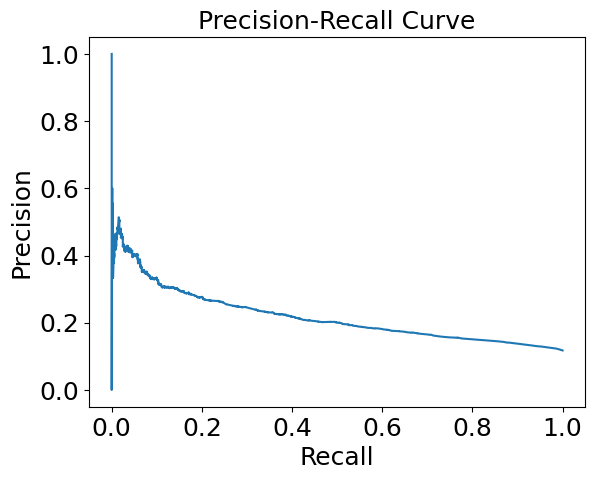

In [ ]:
from sklearn.ensemble import BaggingClassifier
base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    random_state=15
)

# Bagging model
base_bagging = BaggingClassifier(
    estimator=base_estimator,
    random_state=15
)

pipe_base = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_bagging )
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_base,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_base.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_base)

Fold recalls: [0.5741573  0.60449808 0.60291643 0.61009429 0.59614325]
Mean recalls: 0.598, Std: 0.013
Balanced Accuracy: 0.622010349011678

Confusion Matrix:
 [[11160  6521]
 [  911  1442]]

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.63      0.75     17681
           1       0.18      0.61      0.28      2353

    accuracy                           0.63     20034
   macro avg       0.55      0.62      0.51     20034
weighted avg       0.84      0.63      0.69     20034

PR-AUC: 0.21772871530411758


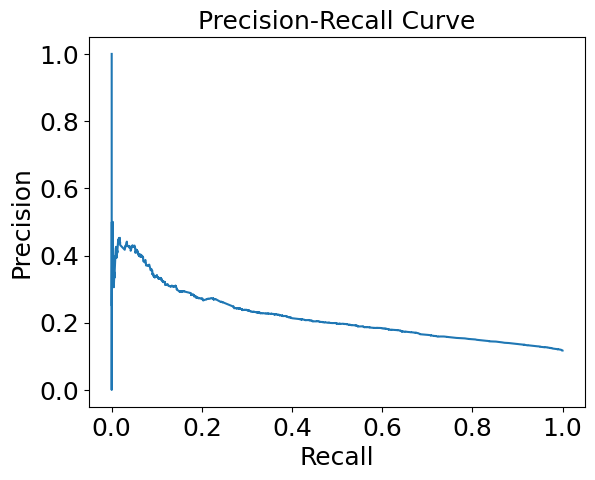

In [ ]:
from sklearn.ensemble import BaggingClassifier
base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=15
)

# Bagging model
base_bagging = BaggingClassifier(
    estimator=base_estimator,
    random_state=15
)

pipe_ba = ImbPipeline([
    ('preprocessor', preprocessor),
    ('model', base_bagging )
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_ba,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_ba.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_ba)

In [ ]:
evaluate_model_with_fairness(pipe_ba)

        dp_ratio   eo_diff  eop_diff
race    0.692749  0.408537  0.408537
gender  0.862396  0.069346  0.069346
age     0.133943  0.678571  0.678571


In [ ]:
evaluate_fairness(pipe_ba, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.405991,0.375641,0.372768
2,0.399687,0.375479,0.411494
3,0.302428,0.280488,0.488372
4,0.281250,0.232759,0.250000
5,0.309904,0.282686,0.433333
6,0.288840,0.283654,0.658537


In [ ]:
evaluate_fairness(pipe_ba, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.071429,0.071429,0.000000
2,0.227273,0.204918,0.500000
3,0.266234,0.225000,0.321429
4,0.305476,0.266234,0.384615
5,0.321134,0.277778,0.356522
6,0.309707,0.280355,0.415335
7,0.369123,0.340553,0.424460
8,0.432459,0.406667,0.387597
9,0.533275,0.513568,0.328638


In [ ]:
evaluate_fairness(pipe_ba, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.424251,0.394450,0.355985
1,0.365872,0.338704,0.425331


Fold recalls: [0.65337079 0.64509051 0.65395401 0.66444814 0.65730028]
Mean recalls: 0.655, Std: 0.006
Balanced Accuracy: 0.6172269891544664

Confusion Matrix:
 [[10014  7667]
 [  781  1572]]

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.57      0.70     17681
           1       0.17      0.67      0.27      2353

    accuracy                           0.58     20034
   macro avg       0.55      0.62      0.49     20034
weighted avg       0.84      0.58      0.65     20034

PR-AUC: 0.20176448563298693


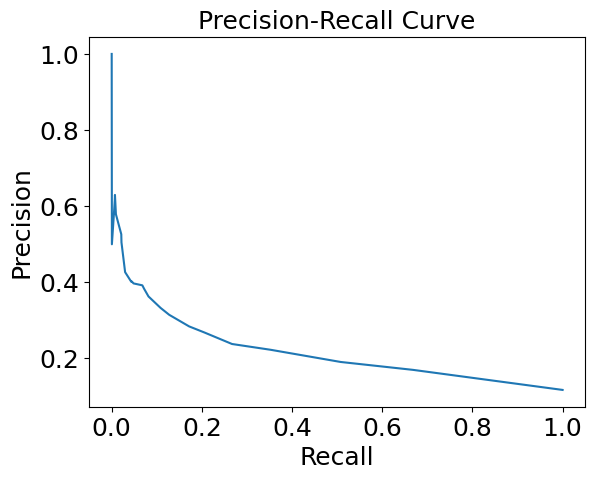

In [ ]:
from sklearn.ensemble import BaggingClassifier
base_estimator = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=15
)

# Bagging model
base_bagging = BaggingClassifier(
    estimator=base_estimator,
    random_state=15
)

pipe_fba = ImbPipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', feature_selector),
    ('model', base_bagging )
])

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(
    pipe_fba,
    X_train.drop(columns=['patient_nbr']),
    y_train,
    groups=groups,
    cv=gkf,
    scoring='recall',
    n_jobs=-1
)

print("Fold recalls:", scores)
print(f'Mean recalls: {scores.mean():.3f}, Std: {scores.std():.3f}')

pipe_fba.fit(X_train.drop(columns=['patient_nbr']), y_train)

evaluate_model(pipe_fba)

In [ ]:
evaluate_model_with_fairness(pipe_fba)

        dp_ratio   eo_diff  eop_diff
race    0.696925  0.213415  0.213415
gender  0.874431  0.062808  0.042646
age     0.212006  0.750000  0.750000


In [ ]:
evaluate_fairness(pipe_fba, 'race')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
race,,,
1,0.470818,0.441706,0.316964
2,0.456897,0.434719,0.370115
3,0.386313,0.363415,0.395349
4,0.328125,0.284483,0.250000
5,0.351438,0.328622,0.433333
6,0.369803,0.353365,0.463415


In [ ]:
evaluate_fairness(pipe_fba, 'age')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
age,,,
1,0.142857,0.142857,0.000000
2,0.333333,0.303279,0.300000
3,0.311688,0.267857,0.250000
4,0.361671,0.326299,0.358974
5,0.379381,0.336842,0.304348
6,0.365485,0.337995,0.376997
7,0.433632,0.406024,0.366906
8,0.493683,0.467778,0.325581
9,0.593081,0.574874,0.279343


In [ ]:
evaluate_fairness(pipe_fba, 'gender')


=== Fairness Metrics by Group for Pipeline ===


,PPR,FPR,FNR
gender,,,
0,0.489350,0.462513,0.312741
1,0.427903,0.399705,0.355388


In [44]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import precision_recall_curve, average_precision_score


def plot_group_cv_pr_curves(models_dict, X_train, y_train, groups, max_recall_points=100):

    mean_recall = np.linspace(0, 1, max_recall_points)

    # Remove group column from features
    X = X_train.drop(columns=['patient_nbr'])

    gkf = GroupKFold(n_splits=5)

    plt.figure(figsize=(10, 7), dpi=150)

    for name, model in models_dict.items():
        precisions = []
        aucs = []

        #  This gives you std for recall (your requested addition)


        #  Proper CV loop for PR curves
        for train_idx, val_idx in gkf.split(X, y_train, groups):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            model.fit(X_tr, y_tr)

            if not hasattr(model, "predict_proba"):
                print(f"{name} does not support predict_proba. Skipping.")
                continue

            y_proba = model.predict_proba(X_val)[:, 1]

            precision, recall, _ = precision_recall_curve(y_val, y_proba)

            # Interpolation
            precision_interp = np.interp(mean_recall, recall[::-1], precision[::-1])
            precisions.append(precision_interp)

            aucs.append(average_precision_score(y_val, y_proba))

        #  Aggregate results
        mean_precision = np.mean(precisions, axis=0)
        std_precision = np.std(precisions, axis=0)
        mean_auc = np.mean(aucs)
        std_auc = np.std(aucs)

        plt.plot(
            mean_recall,
            mean_precision,
            label=f"{name} (PR-AUC={mean_auc:.3f} ± {std_auc:.3f})",
            lw=2
        )

        plt.fill_between(
            mean_recall,
            np.maximum(mean_precision - std_precision, 0),
            np.minimum(mean_precision + std_precision, 1),
            alpha=0.03
        )

    # Baseline
    baseline = np.mean(y_train)

    plt.hlines(
        baseline,
        0,
        1,
        linestyles='dashed',
        colors='black',
        label=f"Baseline ({baseline:.2f})"
    )

    plt.xlabel("Recall", fontsize=14)
    plt.ylabel("Precision", fontsize=14)
    plt.title("Precision-Recall Curves", fontsize=16)
    plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
    plt.legend(fontsize=12)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:42:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [11:43:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

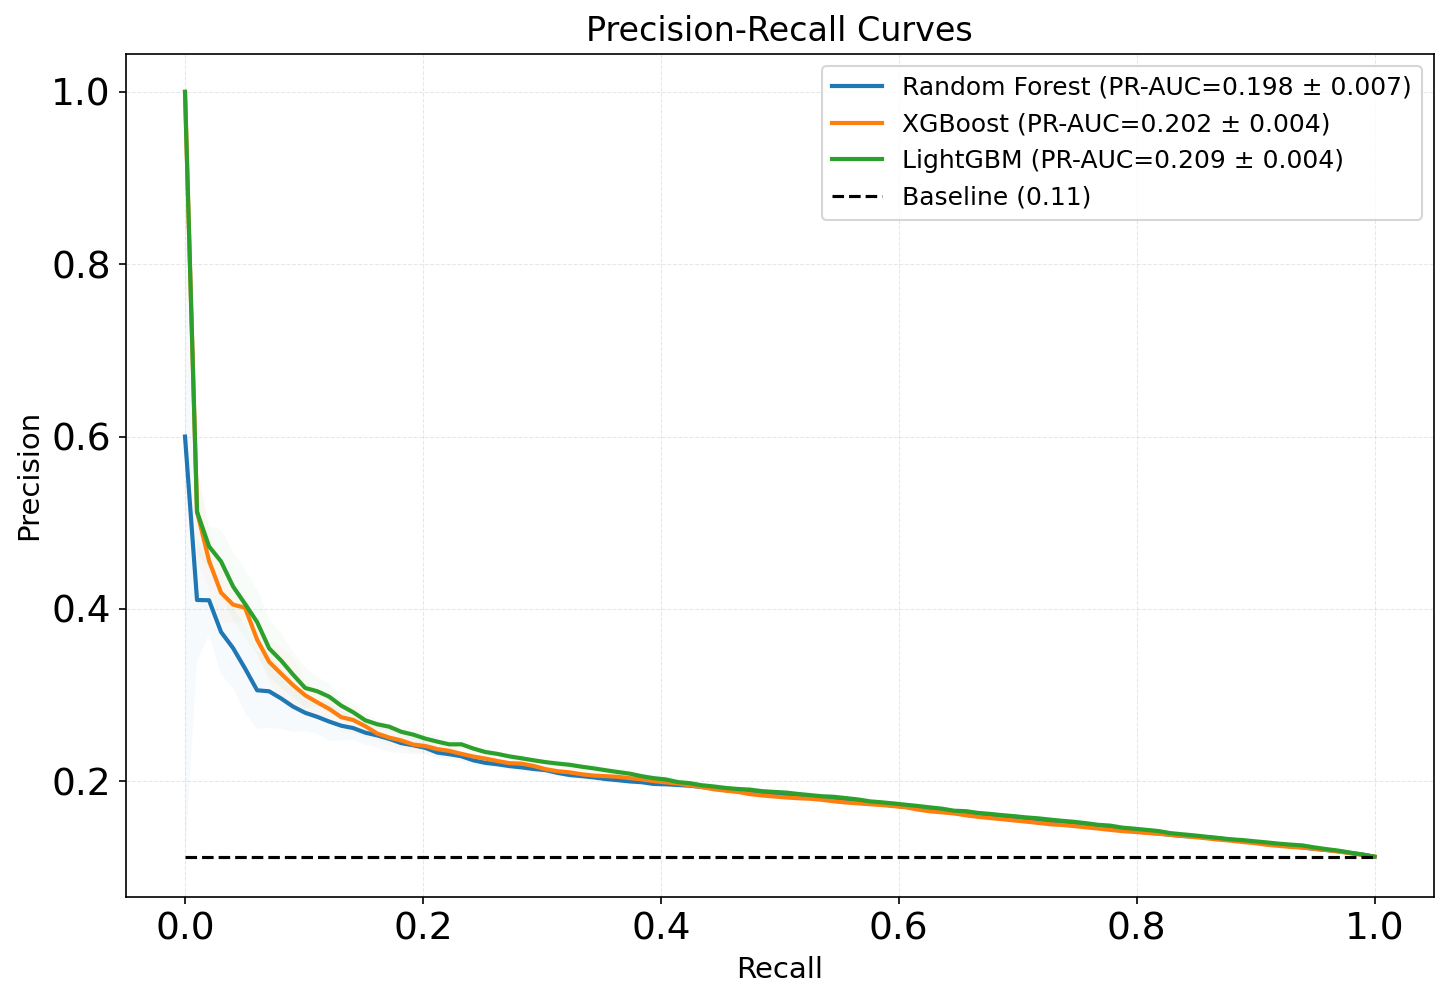

In [45]:
groups = X_train['patient_nbr']

models = {
    "Random Forest": pipe_rf,
    "XGBoost": pipe_xgb,
    "LightGBM":pipe_lg,
}

plot_group_cv_pr_curves(models, X_train, y_train, groups)